# 08 - Logistic Regression 逻辑回归建模

## 目标
用逻辑回归模型预测「用户加购后会不会购买」，量化每个因素（品牌、价格、时间等）的影响权重。

## 建模思路
1. **加载数据** - 从 03_user_behavior_groups.csv 读取
2. **数据清洗** - 排除 B 组、处理缺失值、异常值
3. **加载 Session 特征** - 从原始大表聚合的购物行为特征（浏览深度、犹豫指数等）
4. **特征工程** - 从原始字段中提取对预测有用的特征
5. **编码 & 拆分** - 分类变量编码、训练集/测试集拆分
6. **训练模型** - 用逻辑回归拟合
7. **评估模型** - 准确率、ROC-AUC、分类报告
8. **解读系数** - 把模型结果翻译成业务语言

In [1]:
# ==============================
# 第一步：导入所需库
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- 建模相关的库 ---
# train_test_split: 把数据拆成「训练集」和「测试集」
#   训练集用来教模型学习规律，测试集用来考试看模型学得怎么样
#   如果不拆分，用同一批数据训练+考试，模型会"作弊"（过拟合），分数虚高
from sklearn.model_selection import train_test_split

# StandardScaler: 标准化（把不同量纲的特征拉到同一尺度）
#   比如价格范围 0~300，而小时数范围 0~23，不标准化的话
#   模型会误以为价格"更重要"（因为数值更大），标准化后系数才有可比性
from sklearn.preprocessing import StandardScaler

# LogisticRegression: 逻辑回归模型本身
#   虽然名字里有"回归"，但其实是做分类的（预测 0 或 1）
#   它输出的是一个 0~1 之间的概率值
from sklearn.linear_model import LogisticRegression

# 评估指标：
#   accuracy_score: 准确率 = 预测对的 / 总预测数
#   classification_report: 一张表汇总精确率、召回率、F1
#   roc_auc_score: ROC 曲线下面积，衡量模型区分正负样本的能力（0.5=瞎猜，1=完美）
#   roc_curve: 画 ROC 曲线用的
#   confusion_matrix: 混淆矩阵，看模型把哪些样本分对了/分错了
from sklearn.metrics import (accuracy_score, classification_report,
                             roc_auc_score, roc_curve, confusion_matrix)

# 中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# ==============================
# 第二步：加载数据
# ==============================
df = pd.read_csv(
    r'C:\Users\Administrator\Desktop\data_learn\eCommerce_Events_History\data\interim\03_user_behavior_groups.csv'
)

print(f'原始数据量：{len(df):,} 行, {len(df.columns)} 列')
print(f'\n分组分布：')
print(df['group_type'].value_counts())
print(f'\n缺失率：')
for col in ['brand', 'category_code', 'category_id', 'price']:
    print(f'  {col}: {df[col].isna().mean()*100:.1f}%')

原始数据量：1,154,208 行, 10 列

分组分布：
group_type
B    518495
C    424063
A    211650
Name: count, dtype: int64

缺失率：
  brand: 44.1%
  category_code: 99.0%
  category_id: 0.0%
  price: 0.0%


In [3]:
# ==============================
# 第三步：数据清洗
# ==============================

# --- 3.1 排除 B 组 ---
# B 组（被动流失）= 加购后既没买也没移出，结果不确定
# 逻辑回归需要明确的 Y：买了(1) vs 没买(0)
# B 组是"悬而未决"的状态，放进去会污染模型
df = df[df['group_type'].isin(['A', 'C'])].copy()
print(f'排除 B 组后剩余：{len(df):,} 行')
print(f'A 组（购买）: {(df["group_type"]=="A").sum():,} ({(df["group_type"]=="A").mean()*100:.1f}%)')
print(f'C 组（流失）: {(df["group_type"]=="C").sum():,} ({(df["group_type"]=="C").mean()*100:.1f}%)')

# --- 3.2 创建目标变量 Y ---
# A=1（买了）, C=0（主动移除了）
# 这就是模型要预测的目标：给一条记录，预测它属于 1 还是 0
df['y_purchased'] = (df['group_type'] == 'A').astype(int)
print(f'\n目标变量分布：购买={df["y_purchased"].sum():,}, 流失={len(df)-df["y_purchased"].sum():,}')

# --- 3.3 处理价格异常值 ---
# 之前发现 price 有负值（最低 -79.37），可能是退款数据
# 先看看有多少
neg_price = (df['price'] < 0).sum()
print(f'\n负价格记录：{neg_price} 条')
# 去掉负价格和零价格（零价格没意义，可能是赠品或错误数据）
df = df[df['price'] > 0].copy()
print(f'清洗后剩余：{len(df):,} 行')

# --- 3.4 对价格做对数变换 ---
# 价格分布通常是右偏的（大量低价 + 少量高价），取对数后更接近正态分布
# 好处：让模型对"相对变化"敏感（从 1 涨到 2 vs 从 100 涨到 200 同等重要）
df['log_price'] = np.log(df['price'])

排除 B 组后剩余：635,713 行
A 组（购买）: 211,650 (33.3%)
C 组（流失）: 424,063 (66.7%)

目标变量分布：购买=211,650, 流失=424,063

负价格记录：17 条
清洗后剩余：635,362 行


In [4]:
# ==============================
# 第三点五步：加载 Session 维度特征
# ==============================
# 为什么要加 session 特征？
#   之前的模型（AUC=0.57）只知道"这件商品是什么"（品牌、价格、品类），
#   但不知道"这个人在干嘛"（逛了很久还是随便看看？加了很多还是很挑剔？）
#   同一件商品，在不同购物行为下，命运完全不同：
#     - 用户甲：这次只看了 3 件商品，加购 1 件，5 分钟搞定 -> 目的明确，大概率买
#     - 用户乙：这次逛了 80 件，加购了 15 件 -> 在比价/犹豫，大概率流失

# 这些特征是从原始大表（300万行）按 user_session 聚合后预计算好的
# 已经存到 08_session_features.csv，避免每次重新跑 300 万行
session_df = pd.read_csv(
    r'C:\Users\Administrator\Desktop\data_learn\eCommerce_Events_History\data\interim\08_session_features.csv'
)

print(f'Session 特征表：{len(session_df):,} 个 session')
print(f'\n各特征说明：')
print(f'  session_view             : 这次 session 浏览了几件商品')
print(f'  session_cart             : 这次 session 加购了几件')
print(f'  session_remove_from_cart : 这次 session 从购物车移除几件')
print(f'  session_duration_min     : session 持续时长（分钟）')
print(f'  session_unique_products  : 这次 session 看了多少不同商品')
print(f'  session_avg_price        : 这次 session 浏览商品的平均价格')
print(f'  session_max_price        : 这次 session 浏览商品的最高价格')
print(f'  user_total_sessions      : 该用户这个月总共有几个 session（回头客指标）')

# 合并到主表（按 user_session 左连接）
# 左连接 = 保留主表所有行，匹配不上的填 NaN
df = df.merge(session_df, on='user_session', how='left')

# 处理合并产生的 NaN（匹配不上的 session 填充为 0）
session_fill_cols = ['session_view', 'session_cart', 'session_remove_from_cart',
                       'session_duration_min', 'session_unique_products',
                       'session_avg_price', 'session_max_price', 'user_total_sessions']
df[session_fill_cols] = df[session_fill_cols].fillna(0)

print(f'\n合并后数据量：{len(df):,} 行（应该和合并前一样）')
print(f'匹配成功率：{df["session_view"].notna().mean()*100:.1f}%')

# --- 构造衍生特征 ---

# 购物车移除率：这次 session 里，加购的商品中有多少比例被移除了
# 值越高 -> 用户越犹豫/挑剔
# 分母加 1 防止除以 0（有些 session 可能没有加购行为）
df['session_cart_remove_ratio'] = df['session_remove_from_cart'] / (df['session_cart'] + 1)

# 对偏态特征做对数变换（和 log_price 同理）
# user_total_sessions 和 session_duration_min 都是严重右偏的（少数用户/超长 session 拉高分布）
# log1p = log(1+x)，防止 log(0) 报错
df['log_user_sessions'] = np.log1p(df['user_total_sessions'])
df['log_session_duration'] = np.log1p(df['session_duration_min'].fillna(0))

print(f'\n新增衍生特征：')
print(f'  session_cart_remove_ratio: 均值={df["session_cart_remove_ratio"].mean():.2f}, 中位数={df["session_cart_remove_ratio"].median():.2f}')
print(f'  log_user_sessions: 均值={df["log_user_sessions"].mean():.2f}, 中位数={df["log_user_sessions"].median():.2f}')
print(f'  log_session_duration: 均值={df["log_session_duration"].mean():.2f}, 中位数={df["log_session_duration"].median():.2f}')

Session 特征表：839,865 个 session

各特征说明：
  session_view             : 这次 session 浏览了几件商品
  session_cart             : 这次 session 加购了几件
  session_remove_from_cart : 这次 session 从购物车移除几件
  session_duration_min     : session 持续时长（分钟）
  session_unique_products  : 这次 session 看了多少不同商品
  session_avg_price        : 这次 session 浏览商品的平均价格
  session_max_price        : 这次 session 浏览商品的最高价格
  user_total_sessions      : 该用户这个月总共有几个 session（回头客指标）

合并后数据量：635,403 行（应该和合并前一样）
匹配成功率：100.0%

新增衍生特征：
  session_cart_remove_ratio: 均值=7.36, 中位数=1.00
  log_user_sessions: 均值=2.02, 中位数=1.95
  log_session_duration: 均值=3.12, 中位数=3.11


In [5]:
# ==============================
# 第四步：特征工程
# ==============================
# 特征工程 = 从原始数据中提取/构造对预测有用的变量
# 这一步决定了模型能学到什么，是整个建模中最关键的环节

# --- 4.1 时间特征 ---
df['event_time'] = pd.to_datetime(df['event_time'])

# 小时（0-23）：之前分析发现上午购买率高，晚上流失率高
df['hour'] = df['event_time'].dt.hour

# 星期几（0=周一, 6=周日）：看看工作日和周末有没有差异
df['day_of_week'] = df['event_time'].dt.dayofweek

# --- 4.2 品牌特征 ---
# brand 缺失 44%，但"缺失"本身可能是一个信号
# 比如：没有品牌的商品可能更容易被比价、更容易流失
df['brand_missing'] = df['brand'].isna().astype(int)

# 品牌太多太散，直接用会维度爆炸
# 策略：先把 NaN 填成 'no_brand'，再做 Top N，其余归为 "other"
# 为什么选 15？前 15 个品牌覆盖了大部分数据，
# 太少会丢信息，太多会产生很多稀疏特征

# 【关键顺序】必须先 fillna，再做 Top N 映射！
# 如果反过来（先 apply 再 fillna），NaN 会在 apply 阶段被映射成 'other'，
# 后面的 fillna 就找不到 NaN 了
TOP_N_BRANDS = 15
df['brand_clean'] = df['brand'].fillna('no_brand')  # 第一步：先把 NaN 标记出来
top_brands = df['brand_clean'].value_counts().head(TOP_N_BRANDS).index.tolist()
df['brand_clean'] = df['brand_clean'].apply(         # 第二步：再把小众品牌归为 other
    lambda x: x if x in top_brands else 'other'
)

print(f'品牌处理后分布（Top 15 + other + no_brand）:')
print(df['brand_clean'].value_counts())

# --- 4.3 品类特征 ---
# category_code 缺失 99%，废了，用 category_id 代替
# 同样做 Top N 处理（category_id 没有缺失，不需要 fillna）
TOP_N_CATS = 15
top_cats = df['category_id'].value_counts().head(TOP_N_CATS).index.tolist()
df['cat_clean'] = df['category_id'].apply(
    lambda x: x if x in top_cats else 'other'
)

print(f'\n品类处理后分布:')
print(df['cat_clean'].value_counts())

品牌处理后分布（Top 15 + other + no_brand）:
brand_clean
no_brand     279275
other        126638
runail        49420
irisk         29324
masura        28188
grattol       25498
bpw.style     18540
ingarden      13620
estel         10510
pole          10202
freedecor      8098
kapous         7924
uno            7774
bluesky        7562
haruyama       6607
milv           6223
Name: count, dtype: int64

品类处理后分布:
cat_clean
other                  374149
1487580007675986893     47577
1487580005595612013     26973
1487580005671109489     24296
1487580006317032337     22755
1487580005092295511     21193
1487580005754995573     19117
1602943681873052386     18249
1487580005268456287     13615
1487580005134238553     12071
1487580009286598681     11516
1487580008145748965      8909
1487580005511725929      8886
1487580010100293687      8743
1487580009445982239      8702
1487580008246412266      8652
Name: count, dtype: int64


In [7]:
# ==============================
# 第五步：编码 + 拆分训练集/测试集
# ==============================

# --- 5.1 选出要用到的特征列 ---

# 数值型特征：直接喂给模型（后面会标准化）
# 原来的 3 个 + 新增的 session 维度特征
numeric_features = [
    'log_price', 'hour', 'day_of_week',           # 原来的：商品属性 + 时间
    # --- 新增：session 维度 ---
    'session_view',                # 这次 session 浏览了几件商品（浏览深度）
    'session_cart',                # 这次 session 加购了几件（购买意图强度）
    'session_remove_from_cart',    # 这次 session 移除几件（犹豫/挑剔程度）
    'session_unique_products',     # 这次 session 看了多少不同商品（探索广度）
    'session_avg_price',           # 这次 session 浏览商品的平均价格（消费水平）
    'session_cart_remove_ratio',   # 加购后被移除的比例（犹豫指数）
    'log_user_sessions',           # 该用户总 session 数（回头客程度，已做对数变换）
    'log_session_duration',        # session 时长（已做对数变换）
]

# 分类型特征：需要做 one-hot 编码
categorical_features = ['brand_clean', 'cat_clean']

# 二值特征：brand_missing（已经是 0/1，不需要额外处理）
binary_features = ['brand_missing']

# 合并所有特征
feature_cols = numeric_features + categorical_features + binary_features
print(f'使用的特征数：{len(feature_cols)} 个')
print(f'  数值型({len(numeric_features)}个)：{numeric_features}')
print(f'  分类型({len(categorical_features)}个)：{categorical_features}')
print(f'  二值型({len(binary_features)}个)：{binary_features}')

# --- 5.2 One-Hot 编码 ---
# One-Hot 编码：把分类变量转成多个 0/1 列
# 比如 brand_clean 有 17 个值 -> 变成 17 列，每列是 0 或 1
# 例：brand_clean=runail -> brand_runail=1, 其余=0
#

# drop_first=True：丢掉第一列，避免"多重共线性"
#   原因：如果 17 列里有 16 列都是 0，那第 17 列必然是 1
#   这种"可以用其他列推导出来"的情况叫共线性，会让系数不稳定
#   丢掉一列后，被丢的那个品牌就变成了"参照基准"
df_model = pd.get_dummies(
    df[feature_cols + ['y_purchased']],
    columns=categorical_features,
    drop_first=True,
    dtype=int  # 确保生成的列是 int 而非 bool
)


# 看看编码后有多少列
X_cols = [c for c in df_model.columns if c != 'y_purchased']
print(f'\n编码后特征数：{len(X_cols)} 列')
print(f'特征列名：{X_cols}')

# --- 5.3 拆分 X 和 Y ---
X = df_model[X_cols]
y = df_model['y_purchased']

# --- 5.4 拆分训练集和测试集 ---
# test_size=0.2：80% 训练，20% 测试
# random_state=42：固定随机种子，保证每次拆分一样（可复现）
# stratify=y：按 Y 的比例拆分，保证训练集和测试集中 A/C 的比例一致
#   如果不加这个参数，可能出现测试集里全是 A 或全是 C 的极端情况
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\n训练集：{len(X_train):,} 行（购买率 {y_train.mean()*100:.1f}%）')
print(f'测试集：{len(X_test):,} 行（购买率 {y_test.mean()*100:.1f}%）')

# --- 5.5 标准化 ---
# 只对数值型特征做标准化（分类型已经是 0/1，不需要）
# fit_transform：在训练集上计算均值和标准差，然后变换
# transform：在测试集上只变换（用训练集的均值和标准差，不能重新算）
#   为什么？因为测试集模拟"未来的新数据"，我们不能用未来数据的信息
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print(f'\n标准化完成，共标准化了 {len(numeric_features)} 个数值特征')

使用的特征数：14 个
  数值型(11个)：['log_price', 'hour', 'day_of_week', 'session_view', 'session_cart', 'session_remove_from_cart', 'session_unique_products', 'session_avg_price', 'session_cart_remove_ratio', 'log_user_sessions', 'log_session_duration']
  分类型(2个)：['brand_clean', 'cat_clean']
  二值型(1个)：['brand_missing']

编码后特征数：42 列
特征列名：['log_price', 'hour', 'day_of_week', 'session_view', 'session_cart', 'session_remove_from_cart', 'session_unique_products', 'session_avg_price', 'session_cart_remove_ratio', 'log_user_sessions', 'log_session_duration', 'brand_missing', 'brand_clean_bpw.style', 'brand_clean_estel', 'brand_clean_freedecor', 'brand_clean_grattol', 'brand_clean_haruyama', 'brand_clean_ingarden', 'brand_clean_irisk', 'brand_clean_kapous', 'brand_clean_masura', 'brand_clean_milv', 'brand_clean_no_brand', 'brand_clean_other', 'brand_clean_pole', 'brand_clean_runail', 'brand_clean_uno', 'cat_clean_1487580005134238553', 'cat_clean_1487580005268456287', 'cat_clean_1487580005511725929', 'cat_

In [8]:
# ==============================
# 第六步：训练逻辑回归模型
# ==============================

# LogisticRegression 参数说明：
#   max_iter=1000: 最大迭代次数（默认 100 有时不够用，会报收敛警告）
#   solver='lbfgs': 优化算法（默认值，适合中小规模数据）
#   penalty='l2': L2 正则化（防止过拟合，给系数加一个"不要太大"的约束）
#   C=1.0: 正则化强度的倒数（C 越小 -> 正则化越强 -> 系数越小 -> 更保守）
#          1.0 是默认值，后续可以通过调参优化
#   random_state=42: 固定随机种子
model = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    penalty='l2',
    C=1.0,
    random_state=42
)

# fit = 训练（让模型在训练集上学习特征和 Y 之间的关系）
model.fit(X_train_scaled, y_train)

print('模型训练完成!')
print(f'特征数: {len(X_cols)}')
print(f'训练样本数: {len(X_train):,}')

模型训练完成!
特征数: 42
训练样本数: 508,322


In [9]:
# ==============================
# 第七步：评估模型
# ==============================

# --- 7.1 在测试集上做预测 ---
# predict: 返回分类结果（0 或 1）
# predict_proba: 返回概率值（属于每个类别的概率）
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]  # 取"购买"的概率（第 1 列）

# --- 7.2 准确率 ---
acc = accuracy_score(y_test, y_pred)
print(f'准确率 (Accuracy): {acc:.4f}')
print(f'  -> 含义：模型预测对了 {acc*100:.1f}% 的样本')

# --- 7.3 分类报告 ---
# 比准确率更有用，因为它分别看了每个类别的表现：
#   Precision（精确率）= 预测为正的里面，真正为正的比例 -> "预测购买的用户中，多少真的买了"
#   Recall（召回率）= 真正为正的里面，被预测出来的比例 -> "真正购买的用户中，多少被模型抓到了"
#   F1 = Precision 和 Recall 的调和平均，综合衡量
print(f'\n分类报告:')
print(classification_report(y_test, y_pred, target_names=['流失(0)', '购买(1)']))

# --- 7.4 ROC-AUC ---
# ROC 曲线：横轴是假阳性率（误报），纵轴是真阳性率（命中率）
# AUC 值：曲线下面积，0.5=瞎猜，1=完美
#   0.5-0.6: 基本没用
#   0.6-0.7: 一般
#   0.7-0.8: 还行
#   0.8-0.9: 不错
#   0.9+:    很好
auc = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC: {auc:.4f}')
print(f'  -> 含义：随机取一个购买用户和一个流失用户，模型给购买用户打更高分的概率是 {auc*100:.1f}%')
print(f'  -> 之前无 session 特征时 AUC = 0.5707')

# --- 7.5 混淆矩阵 ---
# 四个格子：
#   TN(真负) = 实际流失，预测流失 -> 正确
#   FP(假正) = 实际流失，预测购买 -> 误报
#   FN(假负) = 实际购买，预测流失 -> 漏报
#   TP(真正) = 实际购买，预测购买 -> 正确
cm = confusion_matrix(y_test, y_pred)
print(f'\n混淆矩阵:')
print(f'                    预测流失    预测购买')
print(f'  实际流失     {cm[0][0]:>8,}  {cm[0][1]:>8,}')
print(f'  实际购买     {cm[1][0]:>8,}  {cm[1][1]:>8,}')

准确率 (Accuracy): 0.7986
  -> 含义：模型预测对了 79.9% 的样本

分类报告:
              precision    recall  f1-score   support

       流失(0)       0.81      0.91      0.86     84772
       购买(1)       0.76      0.57      0.65     42309

    accuracy                           0.80    127081
   macro avg       0.79      0.74      0.76    127081
weighted avg       0.79      0.80      0.79    127081

ROC-AUC: 0.8428
  -> 含义：随机取一个购买用户和一个流失用户，模型给购买用户打更高分的概率是 84.3%
  -> 之前无 session 特征时 AUC = 0.5707

混淆矩阵:
                    预测流失    预测购买
  实际流失       77,342     7,430
  实际购买       18,170    24,139


In [10]:
# ==============================
# 第八步：解读模型系数（最重要的环节）
# ==============================
# 逻辑回归的最大优点：系数可以直接解释！
#
# 系数 (coef) 的含义：
#   正值 -> 该特征增加了购买的概率
#   负值 -> 该特征降低了购买的概率（增加了流失风险）
#
# 优势比 OR (Odds Ratio) = e^系数：
#   OR > 1 -> 该特征让购买的可能性增加了多少倍
#   OR < 1 -> 该特征让购买的可能性降低了多少倍
#   OR = 1 -> 没有影响
#   例：OR=1.5 表示购买的可能性提高了 50%
#   例：OR=0.7 表示购买的可能性降低了 30%（1-0.7=0.3）

# 提取系数
coef_df = pd.DataFrame({
    '特征': X_cols,
    '系数': model.coef_[0],
    'OR(优势比)': np.exp(model.coef_[0])
})

# 按系数从大到小排序
coef_df = coef_df.sort_values('系数', ascending=False).reset_index(drop=True)

# 加上截距（基准线）
intercept = model.intercept_[0]
print(f'截距 (Intercept): {intercept:.4f}')
print(f'  -> 含义：当所有特征都为 0 时的基准 log-odds')

print(f'\n各特征的系数和优势比：')
print('=' * 70)
for _, row in coef_df.iterrows():
    direction = '↑ 促进购买' if row['系数'] > 0 else '↓ 促进流失'
    print(f"{row['特征']:<35} 系数={row['系数']:>7.3f}  OR={row['OR(优势比)']:>6.3f}  {direction}")

截距 (Intercept): -2.6065
  -> 含义：当所有特征都为 0 时的基准 log-odds

各特征的系数和优势比：
session_unique_products             系数=  3.867  OR=47.797  ↑ 促进购买
cat_clean_1487580009286598681       系数=  0.400  OR= 1.493  ↑ 促进购买
cat_clean_1487580009445982239       系数=  0.274  OR= 1.315  ↑ 促进购买
cat_clean_1487580010100293687       系数=  0.271  OR= 1.312  ↑ 促进购买
brand_clean_uno                     系数=  0.270  OR= 1.310  ↑ 促进购买
brand_clean_bpw.style               系数=  0.237  OR= 1.268  ↑ 促进购买
brand_clean_kapous                  系数=  0.227  OR= 1.255  ↑ 促进购买
brand_clean_freedecor               系数=  0.223  OR= 1.250  ↑ 促进购买
brand_clean_runail                  系数=  0.187  OR= 1.205  ↑ 促进购买
brand_clean_estel                   系数=  0.184  OR= 1.202  ↑ 促进购买
cat_clean_1602943681873052386       系数=  0.178  OR= 1.195  ↑ 促进购买
cat_clean_1487580005268456287       系数=  0.161  OR= 1.174  ↑ 促进购买
brand_clean_other                   系数=  0.126  OR= 1.135  ↑ 促进购买
brand_clean_milv                    系数=  0.111  OR= 1.117  ↑ 促进购买
cat_cle

In [11]:
# ==============================
# 第八点五步：保存模型结果到硬盘
# ==============================
# print 适合当场看，CSV 适合以后复查、筛选和写报告。

# --- 1. 保存完整系数解释表 ---
coef_output = coef_df.copy()
coef_output['方向'] = np.where(coef_output['系数'] > 0, '促进购买', '促进流失')

coef_path = r'C:\Users\Administrator\Desktop\data_learn\eCommerce_Events_History\reports\08_logistic_regression_coef.csv'
coef_output.to_csv(coef_path, index=False, encoding='utf-8-sig')

# --- 2. 保存模型评估摘要 ---
tn, fp, fn, tp = cm.ravel()
purchase_precision = tp / (tp + fp)
purchase_recall = tp / (tp + fn)
purchase_f1 = 2 * purchase_precision * purchase_recall / (purchase_precision + purchase_recall)
loss_precision = tn / (tn + fn)
loss_recall = tn / (tn + fp)
loss_f1 = 2 * loss_precision * loss_recall / (loss_precision + loss_recall)

metrics_summary = pd.DataFrame([{
    'accuracy': acc,
    'roc_auc': auc,
    'test_samples': len(y_test),
    'actual_loss': int(tn + fp),
    'actual_purchase': int(fn + tp),
    'true_loss_pred_loss': int(tn),
    'true_loss_pred_purchase': int(fp),
    'true_purchase_pred_loss': int(fn),
    'true_purchase_pred_purchase': int(tp),
    'loss_precision': loss_precision,
    'loss_recall': loss_recall,
    'loss_f1': loss_f1,
    'purchase_precision': purchase_precision,
    'purchase_recall': purchase_recall,
    'purchase_f1': purchase_f1,
}])

metrics_path = r'C:\Users\Administrator\Desktop\data_learn\eCommerce_Events_History\reports\08_logistic_regression_metrics.csv'
metrics_summary.to_csv(metrics_path, index=False, encoding='utf-8-sig')

print('已保存模型结果：')
print(f'  系数解释表：{coef_path}')
print(f'  模型评估摘要：{metrics_path}')

已保存模型结果：
  系数解释表：C:\Users\Administrator\Desktop\data_learn\eCommerce_Events_History\reports\08_logistic_regression_coef.csv
  模型评估摘要：C:\Users\Administrator\Desktop\data_learn\eCommerce_Events_History\reports\08_logistic_regression_metrics.csv


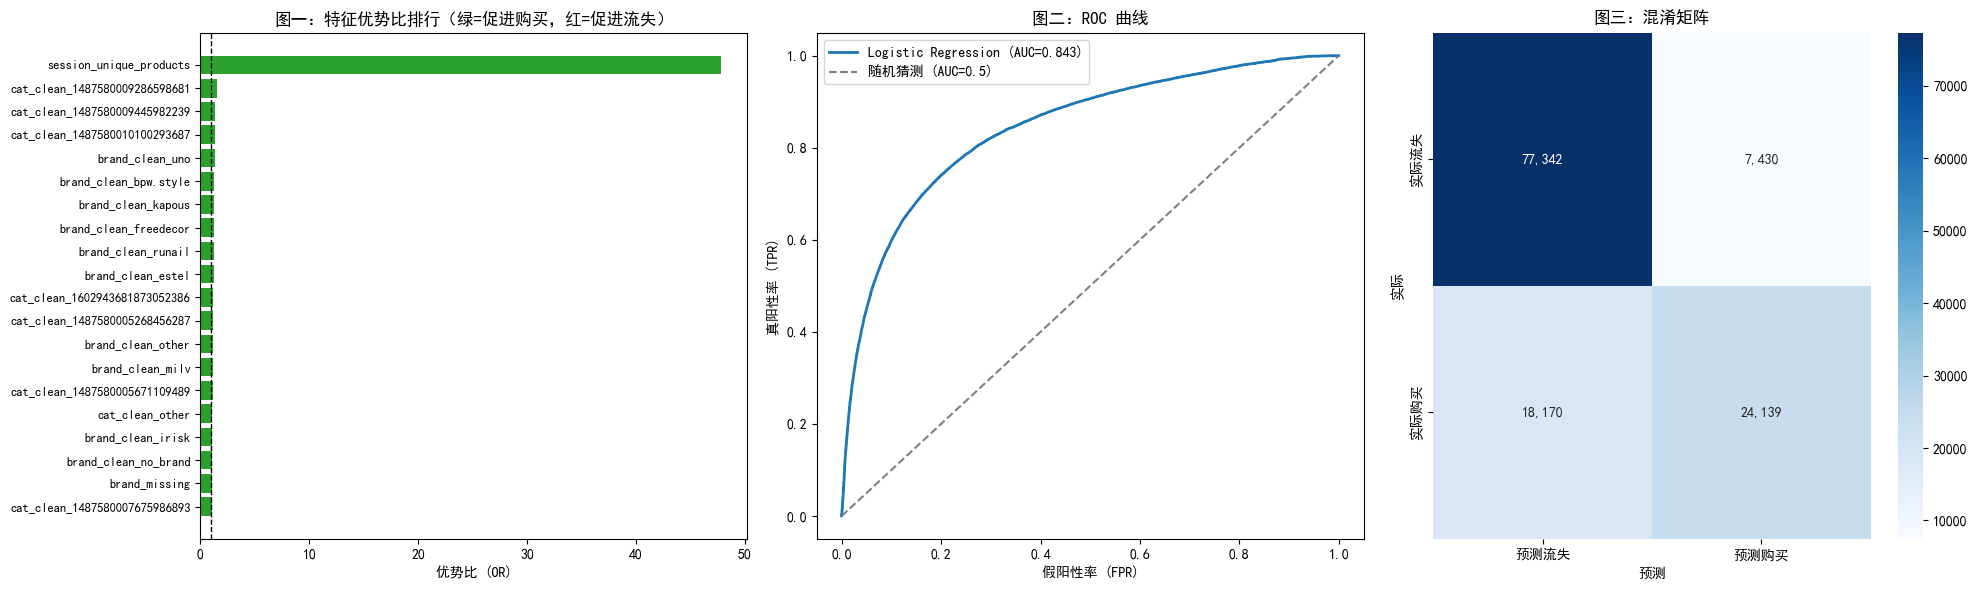

In [12]:
# ==============================
# 第九步：可视化
# ==============================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- 图一：特征重要性（OR 值排序） ---
# 以 OR=1 为分界线，大于 1 的在右边（促进购买），小于 1 的在左边（促进流失）
ax1 = axes[0]
plot_df = coef_df.copy()

# 只显示影响最大的 Top 20（太多看不清）
plot_df = plot_df.sort_values('OR(优势比)', ascending=True).tail(20)

colors = ['#2ca02c' if or_val > 1 else '#d62728' for or_val in plot_df['OR(优势比)']]
ax1.barh(range(len(plot_df)), plot_df['OR(优势比)'], color=colors)
ax1.set_yticks(range(len(plot_df)))
ax1.set_yticklabels(plot_df['特征'], fontsize=9)
ax1.axvline(x=1, color='black', linestyle='--', linewidth=1)
ax1.set_xlabel('优势比 (OR)')
ax1.set_title('图一：特征优势比排行（绿=促进购买，红=促进流失）')

# --- 图二：ROC 曲线 ---
ax2 = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax2.plot(fpr, tpr, color='#1f77b4', linewidth=2, label=f'Logistic Regression (AUC={auc:.3f})')
ax2.plot([0, 1], [0, 1], color='gray', linestyle='--', label='随机猜测 (AUC=0.5)')
ax2.set_xlabel('假阳性率 (FPR)')
ax2.set_ylabel('真阳性率 (TPR)')
ax2.set_title('图二：ROC 曲线')
ax2.legend()

# --- 图三：混淆矩阵热力图 ---
ax3 = axes[2]
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax3,
            xticklabels=['预测流失', '预测购买'],
            yticklabels=['实际流失', '实际购买'])
ax3.set_title('图三：混淆矩阵')
ax3.set_ylabel('实际')
ax3.set_xlabel('预测')

plt.tight_layout()
plt.savefig(
    r'C:\Users\Administrator\Desktop\data_learn\eCommerce_Events_History\reports\08_logistic_regression_results.png',
    dpi=300
)
plt.show()

In [ ]:
# ==============================
# 第十步：业务结论总结
# ==============================

print('=' * 60)
print('【Logistic Regression 建模结论（含 Session 特征）】')
print('=' * 60)

# 找出影响最大的正负特征
top_positive = coef_df.head(8)
top_negative = coef_df.tail(8).sort_values('系数')

print(f'\n模型表现：')
print(f'  准确率: {acc:.4f}')
print(f'  ROC-AUC: {auc:.4f}')
print(f'  （之前无 session 特征时：AUC = 0.5707）')

print(f'\n最促进购买的 8 个特征（OR 最大）:')
for _, row in top_positive.iterrows():
    pct = (row['OR(优势比)'] - 1) * 100
    print(f'  {row["特征"]:<35} OR={row["OR(优势比)"]:.3f} (购买可能性 +{pct:.1f}%)')

print(f'\n最促进流失的 8 个特征（OR 最小）:')
for _, row in top_negative.iterrows():
    pct = (1 - row['OR(优势比)']) * 100
    print(f'  {row["特征"]:<35} OR={row["OR(优势比)"]:.3f} (购买可能性 -{pct:.1f}%)')

print(f'\n' + '=' * 60)
print('【Session 维度特征专项分析】')
print('=' * 60)

# 单独看 session 特征的影响
session_keywords = ['session', 'log_user', 'log_session']
session_coefs = coef_df[coef_df['特征'].apply(lambda x: any(k in x for k in session_keywords))]
print(f'\nSession 维度特征的影响（标准化系数可直接比较大小）:')
print(f'{"特征":<35} {"系数":>8}  {"方向"}')
for _, row in session_coefs.iterrows():
    direction = '↑ 促进购买' if row['系数'] > 0 else '↓ 促进流失'
    print(f"  {row['特征']:<33} {row['系数']:>8.3f}  {direction}")

print(f'\n对比之前描述性分析的结论：')
print(f'  之前（描述统计）：品牌 > 价格 > 时间（定性判断）')
print(f'  现在（逻辑回归）：用系数精确量化每个因素的影响')
print(f'  新增 session 维度后：购物行为模式成为最强预测信号')
print('=' * 60)

【Logistic Regression 建模结论（含 Session 特征）】

模型表现：
  准确率: 0.7986
  ROC-AUC: 0.8428
  （之前无 session 特征时：AUC = 0.5707）

最促进购买的 8 个特征（OR 最大）:
  session_unique_products             OR=47.797 (购买可能性 +4679.7%)
  cat_clean_1487580009286598681       OR=1.493 (购买可能性 +49.3%)
  cat_clean_1487580009445982239       OR=1.315 (购买可能性 +31.5%)
  cat_clean_1487580010100293687       OR=1.312 (购买可能性 +31.2%)
  brand_clean_uno                     OR=1.310 (购买可能性 +31.0%)
  brand_clean_bpw.style               OR=1.268 (购买可能性 +26.8%)
  brand_clean_kapous                  OR=1.255 (购买可能性 +25.5%)
  brand_clean_freedecor               OR=1.250 (购买可能性 +25.0%)

最促进流失的 8 个特征（OR 最小）:
  session_cart_remove_ratio           OR=0.000 (购买可能性 -100.0%)
  session_remove_from_cart            OR=0.003 (购买可能性 -99.7%)
  session_cart                        OR=0.334 (购买可能性 -66.6%)
  session_view                        OR=0.526 (购买可能性 -47.4%)
  cat_clean_1487580005134238553       OR=0.653 (购买可能性 -34.7%)
  brand_clean_masura             

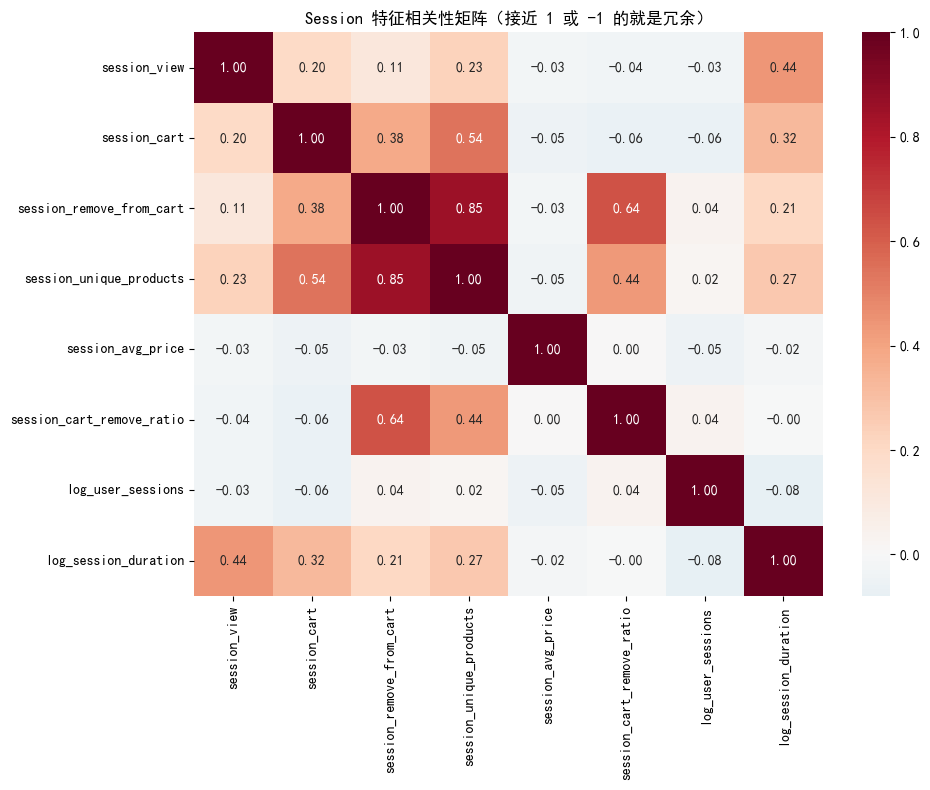

In [ ]:
# 检查 session 特征之间的相关性
# 相关性接近 1 = 两个特征说的是同一件事，留一个就够
session_cols = ['session_view', 'session_cart', 'session_remove_from_cart',
                  'session_unique_products', 'session_avg_price',
                  'session_cart_remove_ratio', 'log_user_sessions', 'log_session_duration']

corr = df[session_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Session 特征相关性矩阵（接近 1 或 -1 的就是冗余）')
plt.tight_layout()
plt.show()

## 学习笔记

### 逻辑回归 vs 你之前做的分析

| | 之前的交叉分析 | 逻辑回归 |
|---|---|---|
| 方法 | 分组统计 + 比值对比 | 建模 + 系数估计 |
| 控制变量 | 每次只能控制一个（如固定价格看品牌） | 同时控制所有变量 |
| 输出 | "A 比 B 高" | "A 比 B 高多少，统计上是否显著" |
| 可落地 | 指导思路 | 可以给新数据打概率分 |

### Session 特征为什么有效

同样的商品（品牌、价格、品类都一样），用户买不买取决于**他这次在干嘛**：
- 浏览了很多但不加购 -> 随便逛逛，不会买
- 加购了很多件 -> 可能只是收藏比价，最终只买一两件
- 购物车移除率高 -> 犹豫不决，容易流失
- session 很短 -> 目的明确，可能直接下单

这些是**行为模式**，不是商品属性，所以之前的模型（只有商品特征）捕捉不到。

### 关键概念速查

- **训练集 vs 测试集**：训练集用来学习，测试集用来考试，防止模型"作弊"
- **标准化**：把不同量纲的特征拉到同一尺度，让系数可比
- **One-Hot 编码**：把分类变量转成多个 0/1 列
- **系数**：正值=促进购买，负值=促进流失
- **OR（优势比）**：e^系数，>1 表示增加购买可能性，<1 表示降低
- **AUC**：0.5=瞎猜，1=完美，衡量模型区分正负样本的能力
- **log1p**：log(1+x)，对严重右偏的特征做对数变换，防止 log(0) 报错